# Vetcove Supplier Dataset Exploration

This notebook profiles the Vetcove landing tables in `heydonto_mdm` and explores the core entities: **order lines**, **catalog items**, **hospitals**, **suppliers**, and **SKU mappings**.

Key questions:
- What are the entity counts and field completeness?
- How do duplicate order-line ids behave and what fields drift across them?
- What is the cardinality between orders, items, hospitals, and suppliers?
- How well do the item exports join to the order history?
- Where is GL Code coverage strong vs absent?

In [1]:
import os
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.options.display.float_format = '{:,.2f}'.format

DB_CONFIG = {
    'username': os.getenv('VETCOVE_DB_USER', 'heydonto_admin'),
    'password': os.getenv('VETCOVE_DB_PASSWORD', 'adminpwd'),
    'host': os.getenv('VETCOVE_DB_HOST', 'localhost'),
    'port': int(os.getenv('VETCOVE_DB_PORT', '5432')),
    'database': os.getenv('VETCOVE_DB_NAME', 'heydonto_dev'),
}

engine = create_engine(URL.create(
    'postgresql+psycopg2',
    username=DB_CONFIG['username'],
    password=DB_CONFIG['password'],
    host=DB_CONFIG['host'],
    port=DB_CONFIG['port'],
    database=DB_CONFIG['database'],
))

def run_sql(query: str) -> pd.DataFrame:
    return pd.read_sql(query, engine)

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype('string')
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip(),
        errors='coerce'
    )

def show_metric_table(df: pd.DataFrame, title: str) -> None:
    display(Markdown(f"### {title}"))
    display(df)

def annotate_barh(ax, fmt='{:,.0f}'):
    for patch in ax.patches:
        value = patch.get_width()
        ax.text(value, patch.get_y() + patch.get_height() / 2, f" {fmt.format(value)}", va='center', fontsize=9)


In [2]:
order_raw = run_sql('select * from heydonto_mdm.vetcove_order_history')
items_raw = run_sql('select * from heydonto_mdm.vetcove_items_exports')

order_raw = order_raw.replace(r'^\s*$', pd.NA, regex=True)
items_raw = items_raw.replace(r'^\s*$', pd.NA, regex=True)

# Parse dates and cast numeric fields.
order_raw['order_date_parsed'] = pd.to_datetime(order_raw['order_date'], errors='coerce', format='mixed')

for column in ['cost_per_dose', 'units', 'unit_price', 'list_price', 'quantity', 'total_price']:
    order_raw[f'{column}_num'] = clean_numeric(order_raw[column])

items_raw['last_purchase_parsed'] = pd.to_datetime(items_raw['last_purchase'], errors='coerce', format='mixed')
for column in ['last_purchase_list_price', 'number_of_orders', 'percentage_of_total_volume', 'quantity', 'total']:
    items_raw[f'{column}_num'] = clean_numeric(items_raw[column])

# Canonical order-line set: deduplicate on vetcove_id (order-line id).
# Some order lines appear in both by_clinic and generic source files.
# Prefer the row with gl_code populated (clinic files always have it),
# then the row with the fewest NULLs across the core data columns.
_data_cols = [c for c in order_raw.columns if not c.endswith('_num') and c != 'order_date_parsed']
order_raw['_has_gl'] = order_raw['gl_code'].notna().astype(int)
order_raw['_null_count'] = order_raw[_data_cols].isna().sum(axis=1)

order_canonical = (
    order_raw
    .sort_values(['vetcove_id', '_has_gl', '_null_count'], ascending=[True, False, True])
    .drop_duplicates(subset=['vetcove_id'], keep='first')
    .drop(columns=['_has_gl', '_null_count'])
    .copy()
)
order_raw = order_raw.drop(columns=['_has_gl', '_null_count'])

# Deduplicate item exports: keep the row with the fewest NULLs per vetcove_id.
_item_data_cols = [c for c in items_raw.columns if not c.endswith('_num') and c != 'last_purchase_parsed']
items_raw['_null_count'] = items_raw[_item_data_cols].isna().sum(axis=1)

items_first = (
    items_raw
    .sort_values(['vetcove_id', '_null_count'])
    .drop_duplicates(subset=['vetcove_id'], keep='first')
    .drop(columns=['_null_count'])
    .copy()
)
items_raw = items_raw.drop(columns=['_null_count'])

display(Markdown('### Loaded raw tables'))
pd.DataFrame([
    {'table': 'heydonto_mdm.vetcove_order_history', 'rows': len(order_raw), 'columns': order_raw.shape[1]},
    {'table': 'heydonto_mdm.vetcove_items_exports', 'rows': len(items_raw), 'columns': items_raw.shape[1]},
])

### Loaded raw tables

,table,rows,columns
0,heydonto_mdm.vetcove_order_history,46961,29
1,heydonto_mdm.vetcove_items_exports,1193,41


## Key semantics

- In `vetcove_items_exports`, `vetcove_id` is the **catalog item id**.
- In `vetcove_order_history`, `vetcove_item_id` is that same **catalog item id**.
- In `vetcove_order_history`, `vetcove_id` is the **order-line id**, not the item id.
- The canonical order-line set deduplicates on `vetcove_id`, preferring rows that have `gl_code` populated (which naturally favours clinic-sourced rows over generic ones), then rows with the fewest NULLs.


In [3]:
entity_summary = pd.DataFrame([
    {'entity': 'order_history_raw_rows', 'count': len(order_raw)},
    {'entity': 'order_history_canonical_rows', 'count': len(order_canonical)},
    {'entity': 'duplicate_order_line_ids_across_files', 'count': len(order_raw) - len(order_canonical)},
    {'entity': 'hospitals', 'count': order_canonical['hospital'].nunique(dropna=True)},
    {'entity': 'orders (hospital + order_number)', 'count': order_canonical[['hospital', 'order_number']].drop_duplicates().shape[0]},
    {'entity': 'po_numbers (hospital + po_number)', 'count': order_canonical.dropna(subset=['hospital', 'po_number'])[['hospital', 'po_number']].drop_duplicates().shape[0]},
    {'entity': 'catalog_items_in_orders', 'count': order_canonical['vetcove_item_id'].nunique(dropna=True)},
    {'entity': 'catalog_items_in_item_exports', 'count': items_raw['vetcove_id'].nunique(dropna=True)},
    {'entity': 'suppliers', 'count': order_canonical['supplier'].nunique(dropna=True)},
    {'entity': 'manufacturers', 'count': order_canonical['manufacturer'].nunique(dropna=True)},
    {'entity': 'primary_categories', 'count': order_canonical['primary_category'].nunique(dropna=True)},
    {'entity': 'secondary_categories', 'count': order_canonical['secondary_category'].nunique(dropna=True)},
    {'entity': 'item_export_categories', 'count': items_raw['category'].nunique(dropna=True)},
])
show_metric_table(entity_summary, 'Entity counts')

order_completeness = pd.DataFrame({
    'field': ['order_date', 'hospital', 'item_name', 'order_number', 'po_number', 'supplier', 'manufacturer', 'manufacturer_number', 'primary_category', 'secondary_category', 'gl_code', 'vetcove_item_id', 'list_price', 'supplier_sku'],
    'pct_non_null': [order_canonical[c].notna().mean() * 100 for c in ['order_date', 'hospital', 'item_name', 'order_number', 'po_number', 'supplier', 'manufacturer', 'manufacturer_number', 'primary_category', 'secondary_category', 'gl_code', 'vetcove_item_id', 'list_price', 'supplier_sku']]
}).sort_values('pct_non_null')

items_completeness = pd.DataFrame({
    'field': ['vetcove_id', 'item_name', 'manufacturer_name', 'manufacturer_no', 'category', 'last_purchase', 'last_purchase_list_price', 'number_of_orders', 'quantity', 'total'],
    'pct_non_null': [items_raw[c].notna().mean() * 100 for c in ['vetcove_id', 'item_name', 'manufacturer_name', 'manufacturer_no', 'category', 'last_purchase', 'last_purchase_list_price', 'number_of_orders', 'quantity', 'total']]
}).sort_values('pct_non_null')

show_metric_table(order_completeness, 'Order-history field completeness (%)')
show_metric_table(items_completeness, 'Item-export field completeness (%)')


### Entity counts

,entity,count
0,order_history_raw_rows,46961
1,order_history_canonical_rows,40904
2,duplicate_order_line_ids_across_files,6057
3,hospitals,14
4,orders (hospital + order_number),8912
5,po_numbers (hospital + po_number),7505
6,catalog_items_in_orders,5288
7,catalog_items_in_item_exports,1097
8,suppliers,19
9,manufacturers,394


### Order-history field completeness (%)

,field,pct_non_null
10,gl_code,17.01
12,list_price,69.45
4,po_number,95.15
6,manufacturer,97.03
7,manufacturer_number,97.35
8,primary_category,98.71
9,secondary_category,98.71
11,vetcove_item_id,99.90
2,item_name,100.00
13,supplier_sku,100.00


### Item-export field completeness (%)

,field,pct_non_null
2,manufacturer_name,91.45
3,manufacturer_no,92.62
4,category,97.23
0,vetcove_id,100.00
1,item_name,100.00
5,last_purchase,100.00
6,last_purchase_list_price,100.00
7,number_of_orders,100.00
8,quantity,100.00
9,total,100.00


### Order-line duplicate summary

,metric,value
0,total_raw_rows,46961
1,unique_order_line_ids,40904
2,ids_appearing_more_than_once,6057
3,excess_rows_from_duplicates,6057
4,canonical_rows_after_dedup,40904


### Fields that drift across duplicate order-line ids

,field,ids_with_differing_values
0,list_price,2087
1,manufacturer_number,52
2,item_name,48
3,unit_measurement,44
4,units,22
5,cost_per_dose,19
6,vetcove_item_id,13
7,item_status,8
8,supplier_sku,1


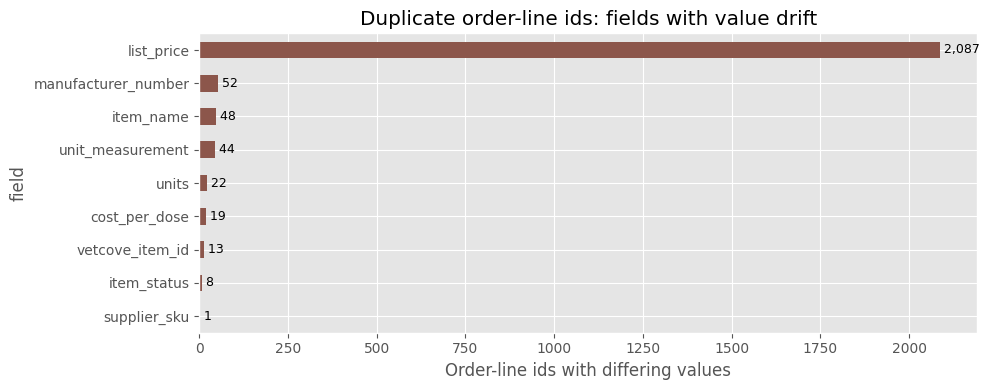

In [4]:
# Order-line duplicate diagnostics: how many vetcove_ids appear more than once?
order_id_freq = order_raw.groupby('vetcove_id').size()
dup_ids = order_id_freq[order_id_freq > 1]

dup_summary = pd.DataFrame([
    {'metric': 'total_raw_rows', 'value': len(order_raw)},
    {'metric': 'unique_order_line_ids', 'value': len(order_id_freq)},
    {'metric': 'ids_appearing_more_than_once', 'value': len(dup_ids)},
    {'metric': 'excess_rows_from_duplicates', 'value': int(dup_ids.sum() - len(dup_ids))},
    {'metric': 'canonical_rows_after_dedup', 'value': len(order_canonical)},
])
show_metric_table(dup_summary, 'Order-line duplicate summary')

# For duplicate ids: do the repeated rows actually differ?
if len(dup_ids) > 0:
    dup_rows = order_raw[order_raw['vetcove_id'].isin(dup_ids.index)].copy()
    comparison_cols = [
        c for c in order_raw.columns
        if not c.endswith('_num') and c not in ('order_date_parsed', 'vetcove_id')
    ]

    # Count fields with more than one distinct value per vetcove_id
    drift_totals = (
        dup_rows
        .groupby('vetcove_id')[comparison_cols]
        .nunique()
        .gt(1)
        .sum()
        .sort_values(ascending=False)
    )
    drift_nonzero = drift_totals[drift_totals > 0].rename_axis('field').reset_index(name='ids_with_differing_values')

    show_metric_table(drift_nonzero, 'Fields that drift across duplicate order-line ids')

    if len(drift_nonzero) > 0:
        fig, ax = plt.subplots(figsize=(10, max(4, len(drift_nonzero) * 0.4)))
        drift_nonzero.sort_values('ids_with_differing_values').plot(
            kind='barh', x='field', y='ids_with_differing_values', ax=ax, color='#8c564b', legend=False
        )
        ax.set_title('Duplicate order-line ids: fields with value drift')
        ax.set_xlabel('Order-line ids with differing values')
        annotate_barh(ax)
        plt.tight_layout()
        plt.show()
else:
    display(Markdown('*No duplicate order-line ids found.*'))

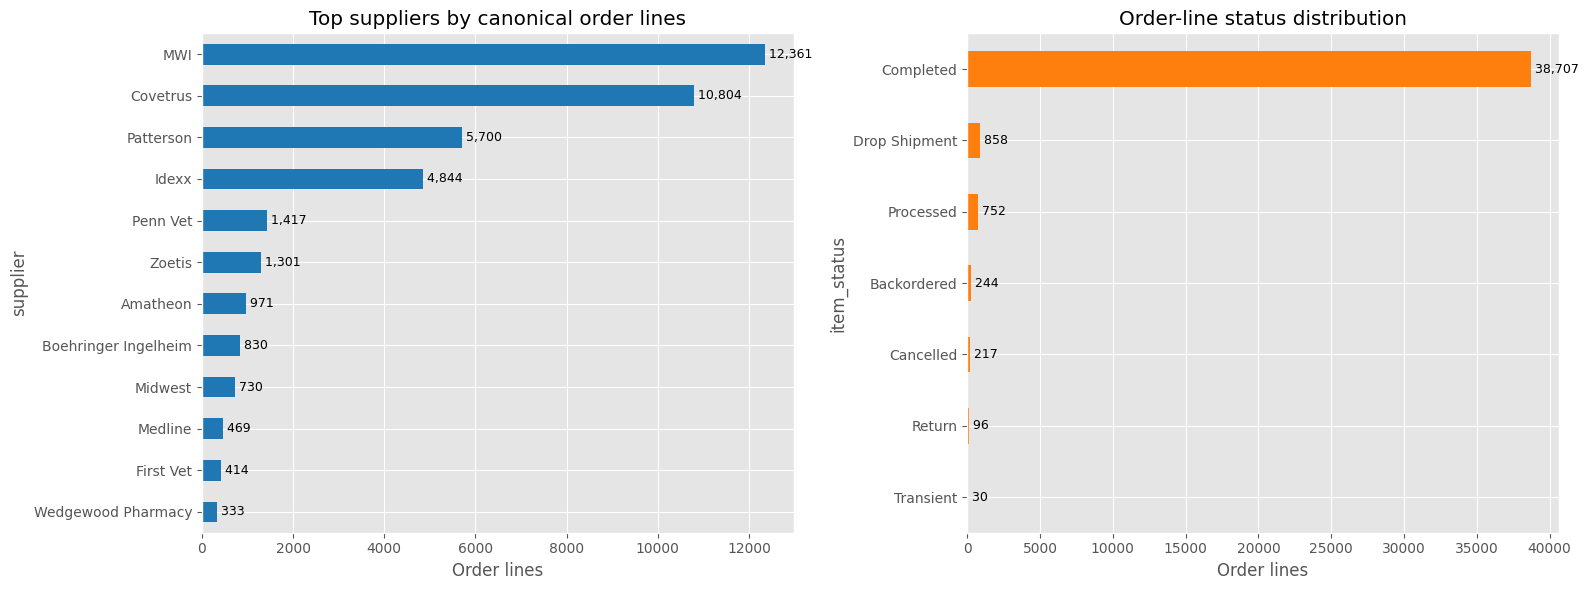

### Supplier line counts

,supplier,order_lines
0,MWI,12361
1,Covetrus,10804
2,Patterson,5700
3,Idexx,4844
4,Penn Vet,1417
5,Zoetis,1301
6,Amatheon,971
7,Boehringer Ingelheim,830
8,Midwest,730
9,Medline,469


In [5]:
supplier_counts = order_canonical.groupby('supplier').size().sort_values()
status_counts = order_canonical.groupby('item_status').size().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
supplier_counts.tail(12).plot(kind='barh', ax=axes[0], color='#1f77b4')
axes[0].set_title('Top suppliers by canonical order lines')
axes[0].set_xlabel('Order lines')
annotate_barh(axes[0])

status_counts.plot(kind='barh', ax=axes[1], color='#ff7f0e')
axes[1].set_title('Order-line status distribution')
axes[1].set_xlabel('Order lines')
annotate_barh(axes[1])

plt.tight_layout()
plt.show()

show_metric_table(supplier_counts.sort_values(ascending=False).reset_index(name='order_lines').head(20), 'Supplier line counts')


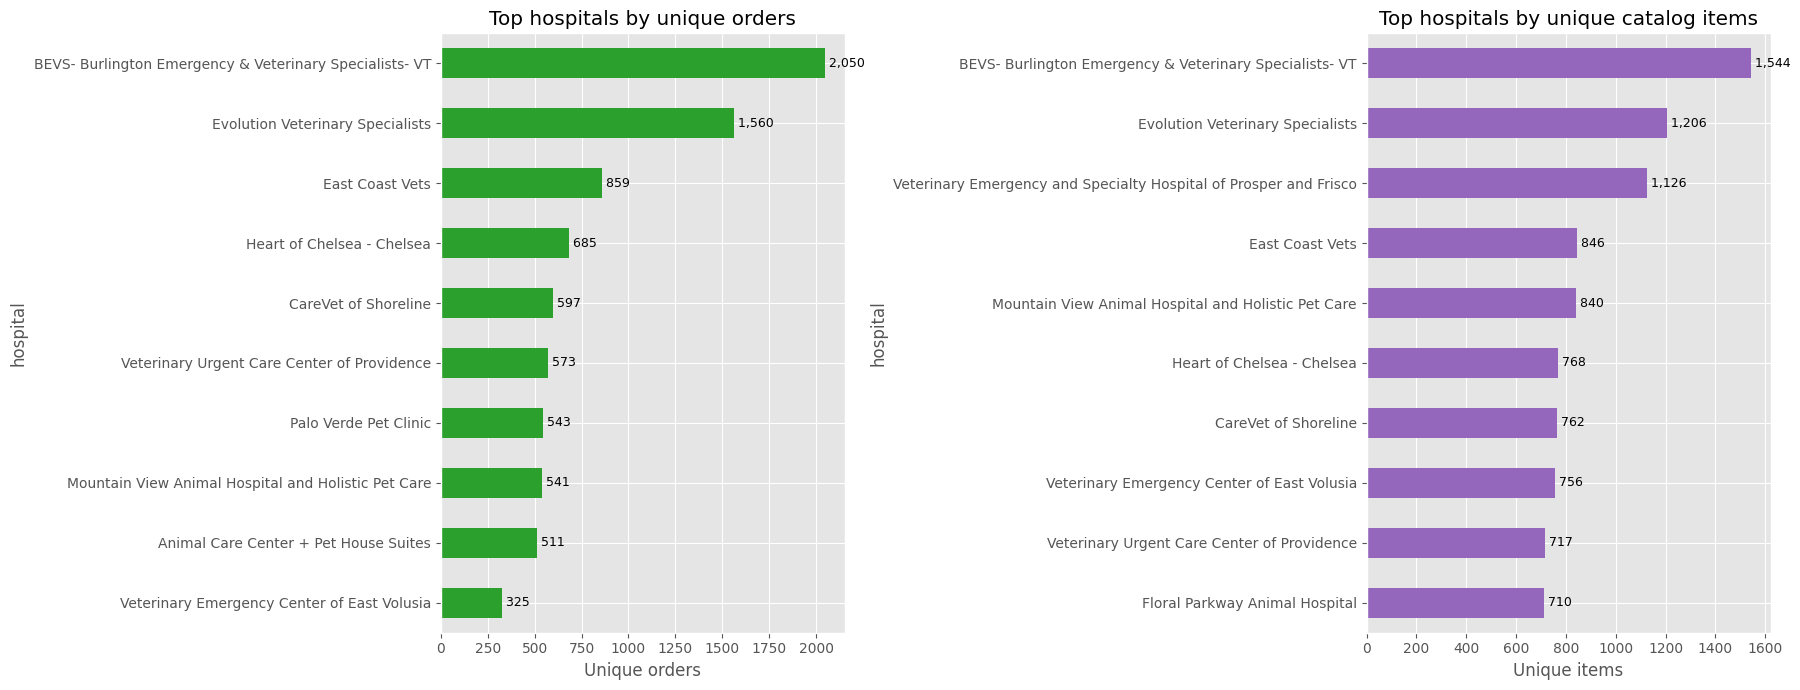

### Hospital-level summary

,hospital,unique_orders,unique_items
13,BEVS- Burlington Emergency & Veterinary Specia...,2050,1544
12,Evolution Veterinary Specialists,1560,1206
11,East Coast Vets,859,846
10,Heart of Chelsea - Chelsea,685,768
9,CareVet of Shoreline,597,762
8,Veterinary Urgent Care Center of Providence,573,717
7,Palo Verde Pet Clinic,543,458
6,Mountain View Animal Hospital and Holistic Pet...,541,840
5,Animal Care Center + Pet House Suites,511,551
4,Veterinary Emergency Center of East Volusia,325,756


In [6]:
orders_per_hospital = order_canonical.groupby('hospital')['order_number'].nunique().sort_values()
items_per_hospital = order_canonical.groupby('hospital')['vetcove_item_id'].nunique().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
orders_per_hospital.tail(10).plot(kind='barh', ax=axes[0], color='#2ca02c')
axes[0].set_title('Top hospitals by unique orders')
axes[0].set_xlabel('Unique orders')
annotate_barh(axes[0])

items_per_hospital.tail(10).plot(kind='barh', ax=axes[1], color='#9467bd')
axes[1].set_title('Top hospitals by unique catalog items')
axes[1].set_xlabel('Unique items')
annotate_barh(axes[1])

plt.tight_layout()
plt.show()

hospital_summary = (
    pd.DataFrame({
        'hospital': orders_per_hospital.index,
        'unique_orders': orders_per_hospital.values,
        'unique_items': items_per_hospital.reindex(orders_per_hospital.index).values,
    })
    .sort_values('unique_orders', ascending=False)
)
show_metric_table(hospital_summary.head(14), 'Hospital-level summary')


### Relationship cardinality summary

,metric,value
0,avg_lines_per_order,4.59
1,max_lines_per_order,255.00
2,avg_hospitals_per_item,2.01
3,max_hospitals_per_item,13.00
4,avg_suppliers_per_item,1.56
5,max_suppliers_per_item,8.00
6,hospital_po_pairs_with_multiple_orders,649.00


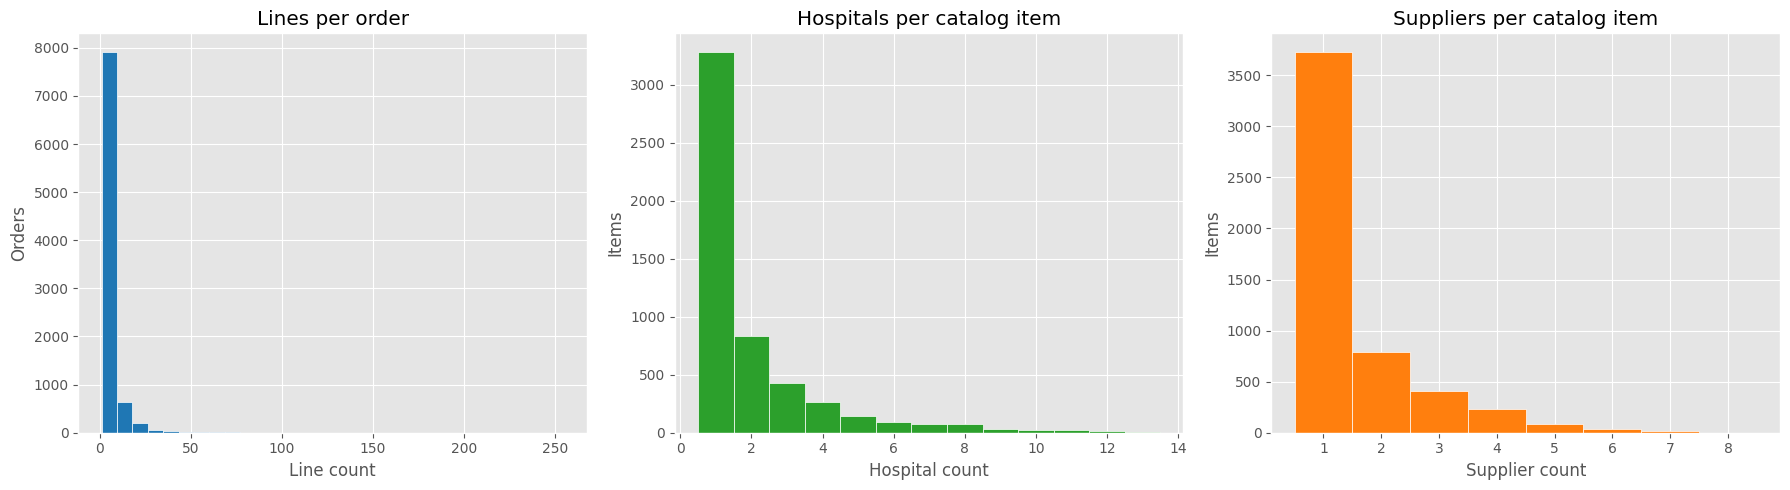

In [7]:
lines_per_order = order_canonical.groupby(['hospital', 'order_number']).size()
hospitals_per_item = order_canonical.groupby('vetcove_item_id')['hospital'].nunique()
suppliers_per_item = order_canonical.groupby('vetcove_item_id')['supplier'].nunique()
po_orders = order_canonical.dropna(subset=['hospital', 'po_number', 'order_number']).groupby(['hospital', 'po_number'])['order_number'].nunique()

relationship_summary = pd.DataFrame([
    {'metric': 'avg_lines_per_order', 'value': lines_per_order.mean()},
    {'metric': 'max_lines_per_order', 'value': lines_per_order.max()},
    {'metric': 'avg_hospitals_per_item', 'value': hospitals_per_item.mean()},
    {'metric': 'max_hospitals_per_item', 'value': hospitals_per_item.max()},
    {'metric': 'avg_suppliers_per_item', 'value': suppliers_per_item.mean()},
    {'metric': 'max_suppliers_per_item', 'value': suppliers_per_item.max()},
    {'metric': 'hospital_po_pairs_with_multiple_orders', 'value': int((po_orders > 1).sum())},
])
show_metric_table(relationship_summary, 'Relationship cardinality summary')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(lines_per_order, bins=30, color='#1f77b4', edgecolor='white')
axes[0].set_title('Lines per order')
axes[0].set_xlabel('Line count')
axes[0].set_ylabel('Orders')

axes[1].hist(hospitals_per_item, bins=range(1, hospitals_per_item.max() + 2), color='#2ca02c', edgecolor='white', align='left')
axes[1].set_title('Hospitals per catalog item')
axes[1].set_xlabel('Hospital count')
axes[1].set_ylabel('Items')

axes[2].hist(suppliers_per_item, bins=range(1, suppliers_per_item.max() + 2), color='#ff7f0e', edgecolor='white', align='left')
axes[2].set_title('Suppliers per catalog item')
axes[2].set_xlabel('Supplier count')
axes[2].set_ylabel('Items')

plt.tight_layout()
plt.show()


### Item-export summary

,metric,value
0,raw_item_export_rows,1193
1,unique_item_export_items,1097
2,duplicate_item_ids_in_exports,82
3,max_duplicate_export_rows_for_one_item,3


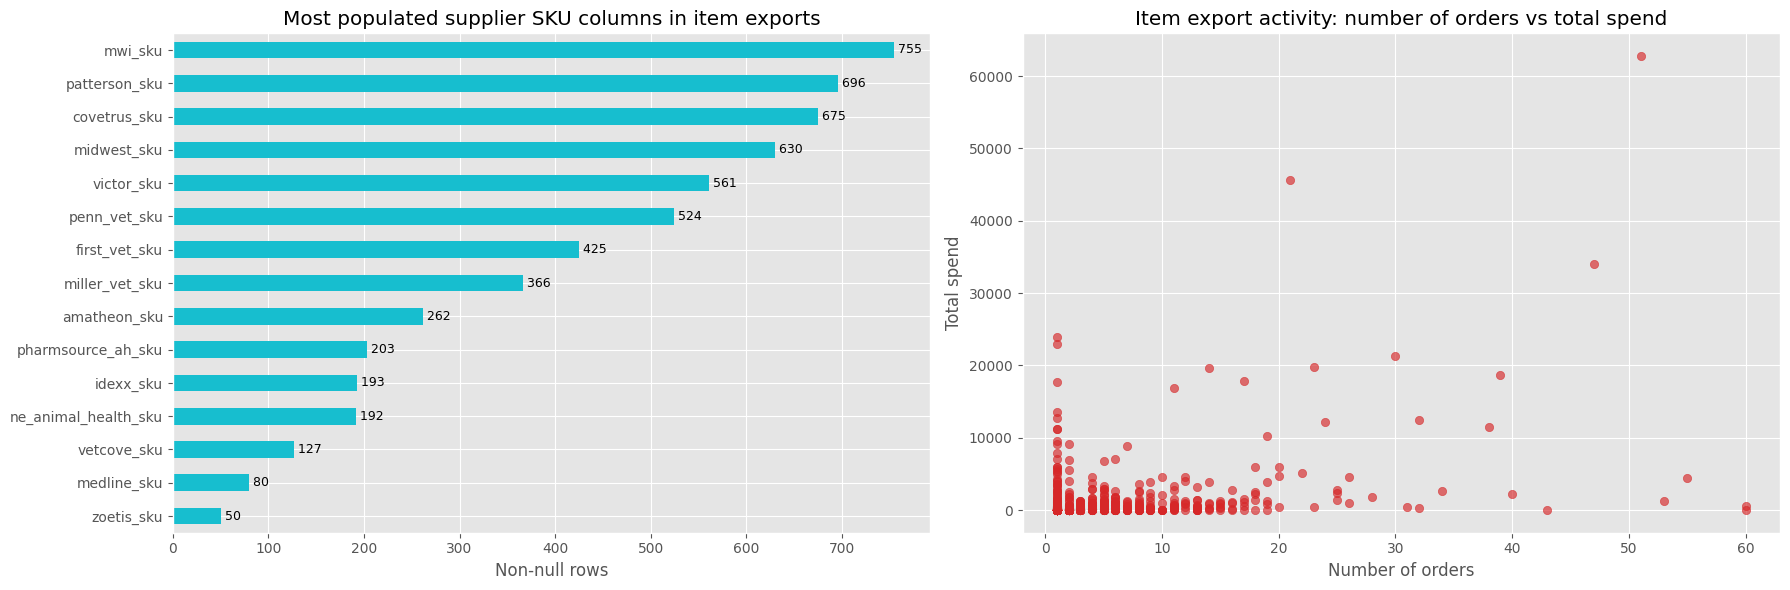

### Supplier SKU coverage in item exports

,supplier_sku_column,non_null_rows
0,mwi_sku,755
1,patterson_sku,696
2,covetrus_sku,675
3,midwest_sku,630
4,victor_sku,561
5,penn_vet_sku,524
6,first_vet_sku,425
7,miller_vet_sku,366
8,amatheon_sku,262
9,pharmsource_ah_sku,203


In [8]:
sku_columns = [column for column in items_raw.columns if column.endswith('_sku')]
sku_coverage = items_raw[sku_columns].notna().sum().sort_values()
item_export_duplicates = items_raw.groupby('vetcove_id').size().sort_values(ascending=False)

item_export_summary = pd.DataFrame([
    {'metric': 'raw_item_export_rows', 'value': len(items_raw)},
    {'metric': 'unique_item_export_items', 'value': items_raw['vetcove_id'].nunique(dropna=True)},
    {'metric': 'duplicate_item_ids_in_exports', 'value': int((item_export_duplicates > 1).sum())},
    {'metric': 'max_duplicate_export_rows_for_one_item', 'value': int(item_export_duplicates.max())},
])
show_metric_table(item_export_summary, 'Item-export summary')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sku_coverage.tail(15).plot(kind='barh', ax=axes[0], color='#17becf')
axes[0].set_title('Most populated supplier SKU columns in item exports')
axes[0].set_xlabel('Non-null rows')
annotate_barh(axes[0])

axes[1].scatter(items_raw['number_of_orders_num'], items_raw['total_num'], alpha=0.65, color='#d62728')
axes[1].set_title('Item export activity: number of orders vs total spend')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Total spend')

plt.tight_layout()
plt.show()

show_metric_table(sku_coverage.sort_values(ascending=False).rename_axis('supplier_sku_column').reset_index(name='non_null_rows'), 'Supplier SKU coverage in item exports')


In [9]:
items_in_orders = set(order_canonical['vetcove_item_id'].dropna())
items_in_exports = set(items_first['vetcove_id'].dropna())
joined_item_ids = items_in_orders & items_in_exports

join_summary = pd.DataFrame([
    {'metric': 'item_export_ids_present_in_orders', 'value': len(joined_item_ids)},
    {'metric': 'item_export_only_ids', 'value': len(items_in_exports - items_in_orders)},
    {'metric': 'order_only_item_ids', 'value': len(items_in_orders - items_in_exports)},
])
show_metric_table(join_summary, 'Cross-table join coverage')

secondary_sets = (
    order_canonical.dropna(subset=['vetcove_item_id'])
    .groupby('vetcove_item_id')['secondary_category']
    .agg(lambda values: {value for value in values.dropna() if value != ''})
)
item_categories = items_first.set_index('vetcove_id')['category']
category_match_flags = pd.Series({
    item_id: item_categories.get(item_id) in secondary_sets.get(item_id, set())
    for item_id in joined_item_ids
})
category_alignment_summary = pd.DataFrame([
    {'metric': 'joined_items', 'value': len(joined_item_ids)},
    {'metric': 'item_export_category_matches_secondary_category', 'value': int(category_match_flags.sum())},
    {'metric': 'item_export_category_mismatch_or_blank', 'value': int((~category_match_flags).sum())},
])
show_metric_table(category_alignment_summary, 'Category alignment between exports and orders')

category_mismatch_examples = (
    items_first[items_first['vetcove_id'].isin(category_match_flags[~category_match_flags].index)]
    [['vetcove_id', 'item_name', 'category']]
    .merge(order_canonical[['vetcove_item_id', 'primary_category', 'secondary_category']].drop_duplicates(), left_on='vetcove_id', right_on='vetcove_item_id', how='left')
    .drop(columns=['vetcove_item_id'])
    .head(15)
)
show_metric_table(category_mismatch_examples, 'Sample category mismatches')


### Cross-table join coverage

,metric,value
0,item_export_ids_present_in_orders,1097
1,item_export_only_ids,0
2,order_only_item_ids,4191


### Category alignment between exports and orders

,metric,value
0,joined_items,1097
1,item_export_category_matches_secondary_category,1062
2,item_export_category_mismatch_or_blank,35


### Sample category mismatches

,vetcove_id,item_name,category,primary_category,secondary_category
0,276230,Freight,NaN,NaN,NaN
1,281760,Composure Pro Chew 60ct FREE,NaN,NaN,NaN
2,290536,Perio Support Powder *FREE,NaN,NaN,NaN
3,373835,STAT FEE,NaN,NaN,NaN
4,381184,iM3 Bur Flame Diamond Fine Friction Grip: 5 Count,Handpiece Accessories,Dentistry,Burs/Finishing
5,433248,"Deluxe Fluid Warming Cabinet, 2.5 Cubic Feet",NaN,NaN,NaN
6,455584,"IV Bottle Holder, Push Button, w/ Extension, 4...",NaN,NaN,NaN
7,503061,Isospire (Isoflurane): 250Ml,Anesthetics,Anesthesia,Anesthesia Systems
8,557872,Ventilator Mount,NaN,NaN,NaN
9,574524,"Gelpi Retractor 7"" 45 Degree Right Angle",NaN,NaN,NaN


### GL Code coverage by hospital

,total_lines,lines_with_gl,pct_with_gl
hospital,,,
East Coast Vets,4023,0,0.00
Evolution Veterinary Specialists,4463,0,0.00
Floral Parkway Animal Hospital,1447,0,0.00
Heart of Chelsea - Chelsea,3069,0,0.00
Mountain View Animal Hospital and Holistic Pet Care,4085,0,0.00
Neuro Vet,257,0,0.00
Palo Verde Pet Clinic,2292,0,0.00
Pilina Vet,295,0,0.00
Veterinary Emergency Center of East Volusia,5018,0,0.00


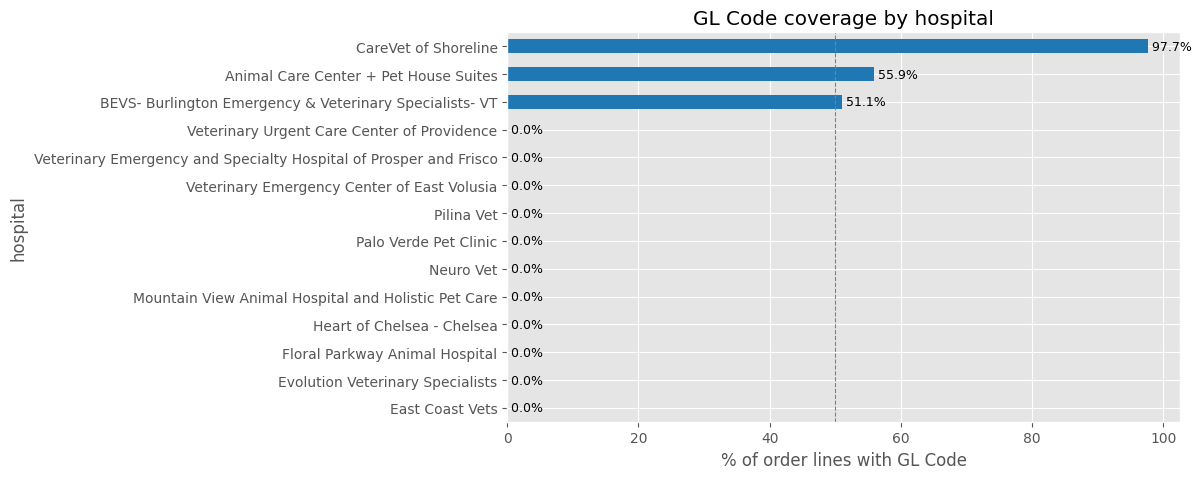

### Attribute consistency for items shared across hospitals

,field,items_with_consistent_value,items_with_inconsistent_values
0,manufacturer,1911,97
1,manufacturer_number,1962,46
2,primary_category,2002,6
3,secondary_category,1986,22


### Sample manufacturer inconsistencies across hospitals

,vetcove_item_id,item_name,hospital,manufacturer
46050,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",BEVS- Burlington Emergency & Veterinary Specia...,Multiple Manufacturers
6946,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",BEVS- Burlington Emergency & Veterinary Specia...,Cardinal Health
14799,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",CareVet of Shoreline,Multiple Manufacturers
20912,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",Evolution Veterinary Specialists,Multiple Manufacturers
40442,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",Floral Parkway Animal Hospital,Multiple Manufacturers
37053,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",Heart of Chelsea - Chelsea,Multiple Manufacturers
33161,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",Veterinary Emergency Center of East Volusia,Multiple Manufacturers
29428,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",Veterinary Emergency and Specialty Hospital of...,Multiple Manufacturers
9847,111222,"Sovereign Sterile Feeding Tube: 5fr x 16""",Veterinary Urgent Care Center of Providence,Cardinal Health
45203,111223,"Sovereign Sterile Feeding: 8fr x 16""",BEVS- Burlington Emergency & Veterinary Specia...,Multiple Manufacturers


### Sample manufacturer_number inconsistencies across hospitals

,vetcove_item_id,item_name,hospital,manufacturer_number
21682,112418,"Phenobarbital Tablets: 1.5 Grain (97.2mg), 100...",East Coast Vets,1903673
13512,112418,"Phenobarbital-CA1 Tablets: 97.2mg, 100 Count",Palo Verde Pet Clinic,51672532501
14001,112418,"Phenobarbital Tablets: 1.5 Grain (97.2mg), 100...",Palo Verde Pet Clinic,1903673
16624,124846,Blue Non-Skid Shoe Covers: 100 Count,CareVet of Shoreline,J730
27636,124846,Blue Non-Skid Shoe Covers: 100 Count,Mountain View Animal Hospital and Holistic Pet...,J730
9977,124846,Blue Non-Skid Shoe Covers: 100 Count,Veterinary Urgent Care Center of Providence,J0730
6898,128336,Pediatric Table Top Scale with Digital LCD Dis...,BEVS- Burlington Emergency & Veterinary Specia...,J0825M
31051,128336,Pediatric Table Top Scale with Digital LCD Dis...,Veterinary Emergency Center of East Volusia,J825M
8846,134887,"Specialist Cast Padding: 2"" x 4yds, 24 Count",BEVS- Burlington Emergency & Veterinary Specia...,9062
23317,134887,"Specialist Cast Padding: 2"" x 4yds, 24 Count",East Coast Vets,9062


### Sample primary_category inconsistencies across hospitals

,vetcove_item_id,item_name,hospital,primary_category
14794,192712,Meloxidyl Oral Suspension for Dogs(Private Lab...,CareVet of Shoreline,Pharmaceuticals
20135,192712,Meloxidyl Oral Suspension for Dogs(Private Lab...,Evolution Veterinary Specialists,Pharmaceuticals
28399,192712,Meloxidyl Oral Suspension for Dogs(Private Lab...,Mountain View Animal Hospital and Holistic Pet...,Parasiticides
7910,30200,PVC Cuffed Endotracheal Tube: 6.5mm,BEVS- Burlington Emergency & Veterinary Specia...,Anesthesia
39549,30200,PVC Cuffed Endotracheal Tube: 6.5mm,Floral Parkway Animal Hospital,Wound Care and White Goods
40707,30200,PVC Cuffed Endotracheal Tube: 6.5mm,Floral Parkway Animal Hospital,Anesthesia
31633,30200,PVC Cuffed Endotracheal Tube: 6.5mm,Veterinary Emergency Center of East Volusia,Anesthesia
43230,5725,Orapac Kit: 2oz,BEVS- Burlington Emergency & Veterinary Specia...,Administration and Transfusion
9215,5725,Orapac Kit: 2oz,BEVS- Burlington Emergency & Veterinary Specia...,Facility Supplies
36115,5725,Orapac Kit: 2oz,Heart of Chelsea - Chelsea,Administration and Transfusion


### Sample secondary_category inconsistencies across hospitals

,vetcove_item_id,item_name,hospital,secondary_category
21228,121291,"Proin Chewable Tablets: 50mg, 180 count",East Coast Vets,"Vitamins, Minerals, and Supplements"
37848,121291,"Proin Chewable Tablets: 50mg, 180 count",Heart of Chelsea - Chelsea,"Vitamins, Minerals, and Supplements"
12440,121291,"Proin Chewable Tablets: 50mg, 180 count",Palo Verde Pet Clinic,Urinary
7307,189393,"Proin Chewable Tablets: 25mg, 60 Count",BEVS- Burlington Emergency & Veterinary Specia...,"Vitamins, Minerals, and Supplements"
9144,189393,"Proin Chewable Tablets: 25mg, 60 Count",BEVS- Burlington Emergency & Veterinary Specia...,Urinary
14777,189393,"Proin Chewable Tablets: 25mg, 60 Count",CareVet of Shoreline,"Vitamins, Minerals, and Supplements"
39979,189393,"Proin Chewable Tablets: 25mg, 60 Count",Floral Parkway Animal Hospital,"Vitamins, Minerals, and Supplements"
29770,189393,"Proin Chewable Tablets: 25mg, 60 Count",Veterinary Emergency and Specialty Hospital of...,"Vitamins, Minerals, and Supplements"
14794,192712,Meloxidyl Oral Suspension for Dogs(Private Lab...,CareVet of Shoreline,Antiinflammatories
20135,192712,Meloxidyl Oral Suspension for Dogs(Private Lab...,Evolution Veterinary Specialists,Antiinflammatories


In [10]:
# GL Code coverage: which hospitals have gl_code populated vs missing?
gl_by_hospital = (
    order_canonical
    .groupby('hospital')
    .agg(
        total_lines=('vetcove_id', 'size'),
        lines_with_gl=('gl_code', lambda s: s.notna().sum()),
    )
    .assign(pct_with_gl=lambda d: d['lines_with_gl'] / d['total_lines'] * 100)
    .sort_values('pct_with_gl')
)

show_metric_table(gl_by_hospital, 'GL Code coverage by hospital')

fig, ax = plt.subplots(figsize=(12, max(4, len(gl_by_hospital) * 0.35)))
gl_by_hospital['pct_with_gl'].plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('GL Code coverage by hospital')
ax.set_xlabel('% of order lines with GL Code')
ax.axvline(x=50, color='grey', linestyle='--', linewidth=0.8)
annotate_barh(ax, fmt='{:,.1f}%')
plt.tight_layout()
plt.show()

# Hospital consistency: do the same catalog items appear at multiple hospitals?
# And if so, do their attributes (manufacturer, category) agree?
multi_hospital_items = (
    order_canonical
    .dropna(subset=['vetcove_item_id'])
    .groupby('vetcove_item_id')
    .filter(lambda g: g['hospital'].nunique() > 1)
)

if len(multi_hospital_items) > 0:
    consistency_fields = ['manufacturer', 'manufacturer_number', 'primary_category', 'secondary_category']
    consistency_check = pd.DataFrame([
        {
            'field': field,
            'items_with_consistent_value': int(
                (multi_hospital_items.groupby('vetcove_item_id')[field].nunique(dropna=True) <= 1).sum()
            ),
            'items_with_inconsistent_values': int(
                (multi_hospital_items.groupby('vetcove_item_id')[field].nunique(dropna=True) > 1).sum()
            ),
        }
        for field in consistency_fields
    ])
    show_metric_table(consistency_check, 'Attribute consistency for items shared across hospitals')

    # Sample inconsistent items
    for field in consistency_fields:
        inconsistent = (
            multi_hospital_items
            .groupby('vetcove_item_id')[field]
            .nunique(dropna=True)
        )
        bad_ids = inconsistent[inconsistent > 1].index[:5]
        if len(bad_ids) > 0:
            examples = (
                multi_hospital_items[multi_hospital_items['vetcove_item_id'].isin(bad_ids)]
                [['vetcove_item_id', 'item_name', 'hospital', field]]
                .drop_duplicates()
                .sort_values(['vetcove_item_id', 'hospital'])
            )
            show_metric_table(examples, f'Sample {field} inconsistencies across hospitals')

In [11]:
supplier_sku_cardinality = (
    order_canonical.dropna(subset=['supplier', 'supplier_sku', 'vetcove_item_id'])
    .groupby(['supplier', 'supplier_sku'])['vetcove_item_id']
    .nunique()
    .reset_index(name='item_count')
)
ambiguous_supplier_skus = supplier_sku_cardinality.query('item_count > 1').sort_values(['item_count', 'supplier', 'supplier_sku'], ascending=[False, True, True])

manufacturer_number_cardinality = (
    order_canonical.dropna(subset=['manufacturer_number', 'vetcove_item_id'])
    .groupby('manufacturer_number')['vetcove_item_id']
    .nunique()
    .reset_index(name='item_count')
)
ambiguous_manufacturer_numbers = manufacturer_number_cardinality.query('item_count > 1').sort_values(['item_count', 'manufacturer_number'], ascending=[False, True])

drift_fields = ['item_name', 'manufacturer', 'manufacturer_number', 'primary_category', 'secondary_category', 'unit_measurement']
drift_summary = pd.DataFrame([
    {
        'field': field,
        'items_with_multiple_distinct_values': int((order_canonical.groupby('vetcove_item_id')[field].nunique(dropna=True) > 1).sum())
    }
    for field in drift_fields
])

show_metric_table(pd.DataFrame([
    {'metric': 'supplier_sku_pairs_mapping_to_multiple_items', 'value': len(ambiguous_supplier_skus)},
    {'metric': 'manufacturer_numbers_mapping_to_multiple_items', 'value': len(ambiguous_manufacturer_numbers)},
]), 'Unsafe business-key counts')
show_metric_table(drift_summary, 'Catalog field drift by vetcove_item_id')
show_metric_table(ambiguous_supplier_skus.head(15), 'Ambiguous supplier SKU examples')
show_metric_table(ambiguous_manufacturer_numbers.head(15), 'Ambiguous manufacturer number examples')


### Unsafe business-key counts

,metric,value
0,supplier_sku_pairs_mapping_to_multiple_items,28
1,manufacturer_numbers_mapping_to_multiple_items,110


### Catalog field drift by vetcove_item_id

,field,items_with_multiple_distinct_values
0,item_name,55
1,manufacturer,109
2,manufacturer_number,50
3,primary_category,7
4,secondary_category,26
5,unit_measurement,36


### Ambiguous supplier SKU examples

,supplier,supplier_sku,item_count
243,Amatheon,69315-0327-05,2
294,Amatheon,86117-0007-11,2
295,Amatheon,86117-0008-10,2
1434,Covetrus,060734,2
1799,Covetrus,072661,2
1800,Covetrus,072662,2
1802,Covetrus,072664,2
2956,MWI,000431,2
4435,MWI,113101,2
4899,MWI,128499,2


### Ambiguous manufacturer number examples

,manufacturer_number,item_count
346,1,3
449,10020412,3
2100,6270,3
3050,C53130S,3
87,00407141230,2
94,00409116301,2
95,00409234402,2
102,00409665305,2
138,00641-6022-25,2
277,067619,2


## Modeling takeaways for the ingestion pipeline

- Treat `vetcove_order_history` as a raw order-line landing table and `vetcove_items_exports` as a raw item snapshot table.
- Build a canonical order-line layer by deduping on `vetcove_id`, preferring rows with `gl_code` populated (clinic-sourced) and then the fewest NULLs.  Duplicate order-line ids exist because the same lines can appear in both clinic-specific and generic extracts.
- Use `vetcove_order_history.vetcove_item_id` &lt;-&gt; `vetcove_items_exports.vetcove_id` as the main item-level join.
- Model `supplier_sku` as a bridge key with caution because some supplier SKU pairs map to multiple catalog items.
- Keep `po_number` as an order attribute, not a primary order key, because it can repeat across multiple orders within a hospital.
- Model item-export `category` separately from the order taxonomy, but keep a mapping to `secondary_category` because most items align there.
- GL Code coverage varies by hospital; some hospitals have full coverage while others have none, reflecting different source extract types.